In [1]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"

GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_latent_20_2025-08-04.h5ad"

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(f"Done reading the ge_adata with scVI...")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
print(f"Renaming mouse.id to donor_id in splice_adata.obs")
# Update gene annotations
ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
rbps = rbps["mouse_gene_name"]

Done reading the ge_adata with scVI...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Renaming mouse.id to donor_id in splice_adata.obs


In [3]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-07-30"
MODEL_ANALYSIS_DATE = "2025-07-31"
PARAM_ID = 0

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files from downstream analysis of model 
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
PERPLEXITY_PATH =  f"{DATA_DIR}/cell_metadata_with_perplexity_param_id_{PARAM_ID}.csv.gz"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)

pi = np.load(PI_VALUES_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
perplexity_df = pd.read_csv(PERPLEXITY_PATH)
perplexity_df = perplexity_df.set_index("cell_id")
leaflet_model = load_model(MODEL_PATH)

splice_adata.obs_names = splice_adata.obs["cell_id"]
assert all(splice_adata.obs_names == perplexity_df.index), "Cell IDs in filtered_splice_adata and perplexity_df do not match or are not in the same order"
splice_adata.obs["perplexity"] = perplexity_df["perplexity"]

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")

MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"
leaflet_model = load_model(MODEL_PATH)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Loading data for param_id 0 from 2025-07-30
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/data
Loading model to device: cpu
Loaded splice_adata: (137936, 35197)
Loaded PI values: (20,)
Loaded diff_spl: (79097, 44)
Loading model to device: cpu
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs


### Add module labels to cell types 

In [4]:
# Always assert after creation or reuse
assert all(splice_adata.obs_names == ge_adata.obs_names)
splice_adata.obs["AgingScore_unweighted"] = ge_adata.obs["AgingScore_unweighted"]
splice_adata.obs["total_counts"] = ge_adata.obs["total_counts"]
splice_adata.obs["nuclear_class_log_norm"] = ge_adata.obs["nuclear_class_log_norm"]
splice_adata.obs["nuclear_score_log_norm"] = ge_adata.obs["nuclear_score_log_norm"]

## Rename factors to be in order that matches PI

In [5]:
# Number of factors (K)
K = splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Reorder X_PHI (cell × K)
splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]

# Generate column names: SP_1, SP_2, ..., SP_K
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"], 
    index=splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)

# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

Sorted pi values with original factor indices:
Rank 1: Factor 2 → PI = 0.1451
Rank 2: Factor 0 → PI = 0.1417
Rank 3: Factor 1 → PI = 0.1131
Rank 4: Factor 6 → PI = 0.0708
Rank 5: Factor 12 → PI = 0.0475
Rank 6: Factor 4 → PI = 0.0439
Rank 7: Factor 13 → PI = 0.0421
Rank 8: Factor 9 → PI = 0.0389
Rank 9: Factor 14 → PI = 0.0385
Rank 10: Factor 3 → PI = 0.0378
Rank 11: Factor 11 → PI = 0.0373
Rank 12: Factor 15 → PI = 0.0368
Rank 13: Factor 7 → PI = 0.0362
Rank 14: Factor 5 → PI = 0.0351
Rank 15: Factor 8 → PI = 0.0350
Rank 16: Factor 10 → PI = 0.0313
Rank 17: Factor 16 → PI = 0.0212
Rank 18: Factor 17 → PI = 0.0178
Rank 19: Factor 18 → PI = 0.0164
Rank 20: Factor 19 → PI = 0.0135
{2: 0, 0: 1, 1: 2, 6: 3, 12: 4, 4: 5, 13: 6, 9: 7, 14: 8, 3: 9, 11: 10, 15: 11, 7: 12, 5: 13, 8: 14, 10: 15, 16: 16, 17: 17, 18: 18, 19: 19}


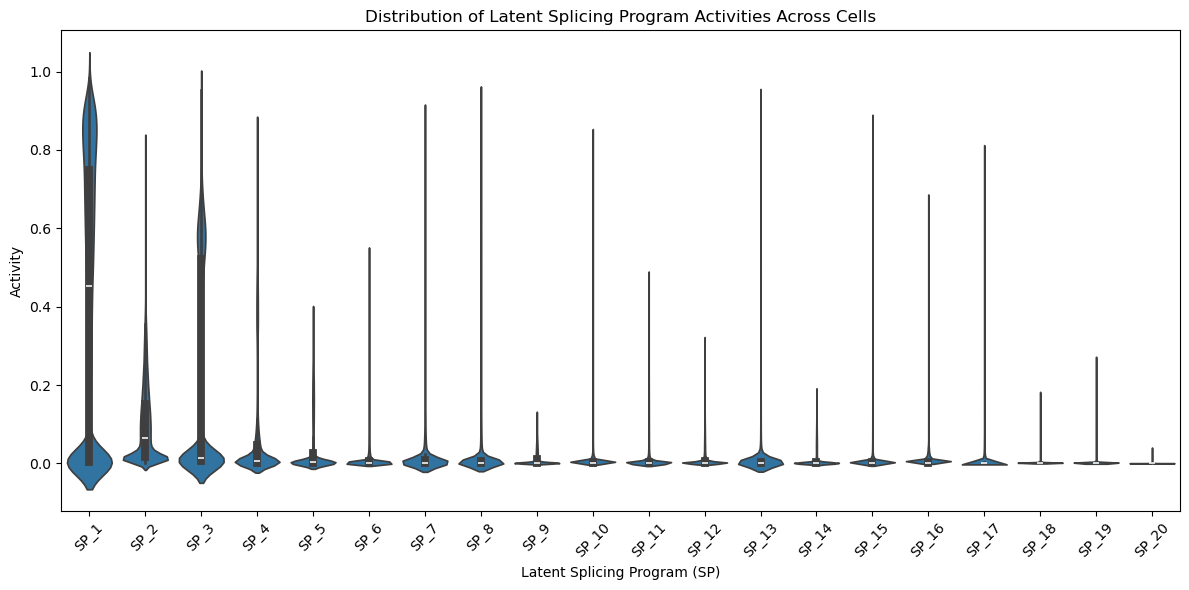

In [6]:
# Extract X_PHI matrix and convert to DataFrame
phi = pd.DataFrame(
    splice_adata.obsm["X_PHI"],
    index=splice_adata.obs["cell_id"]
)
phi.columns = [f"SP_{i+1}" for i in range(phi.shape[1])]

phi_long = phi.reset_index().melt(id_vars="cell_id", var_name="Splicing Program", value_name="Activity")

# Plot
plt.figure(figsize=(12, 6))  # Adjust width as needed
sns.violinplot(data=phi_long, x="Splicing Program", y="Activity", inner="box", scale="width")
plt.xticks(rotation=45)
plt.title("Distribution of Latent Splicing Program Activities Across Cells")
plt.xlabel("Latent Splicing Program (SP)")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

In [7]:
# Clean up Broad Cell Type column
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
splice_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]

# Update ge_adata.obs to match 
ge_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
ge_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
ge_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]
ge_adata.obs["age_group"] = splice_adata.obs["age_group"]

assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [8]:
# Setup
phi_matrix = splice_adata.obsm["X_PHI"]
factor_names = [f"SP_{i+1}" for i in range(phi_matrix.shape[1])]

In [9]:
# Build DataFrame
phi_df = pd.DataFrame(phi_matrix, index=splice_adata.obs_names, columns=factor_names)
phi_df["broad_cell_type"] = splice_adata.obs["broad_cell_type"].values
phi_df["medium_cell_type"] = splice_adata.obs["medium_cell_type"].values
phi_df["age_group"] = splice_adata.obs["age_group"].values

# Output dirs
output_dir_celltype = "./factor_violin_plots_by_celltype"
output_dir_agegroup = "./factor_violin_plots_by_agegroup"
output_dir_factors_by_celltype = "./factor_violin_per_celltype"

os.makedirs(output_dir_factors_by_celltype, exist_ok=True)
os.makedirs(output_dir_celltype, exist_ok=True)
os.makedirs(output_dir_agegroup, exist_ok=True)

In [10]:
# Toggle this to enable or disable plotting
MAKE_PLOTS = True

if MAKE_PLOTS:
    # --- Plot factor activity across broad cell types ---
    for factor in factor_names:
        # Order broad_cell_type by decreasing median activity
        medians = phi_df.groupby("medium_cell_type")[factor].median().sort_values(ascending=False)
        ordered_types = medians.index.tolist()

        plt.figure(figsize=(10, 5))
        sns.violinplot(
            data=phi_df, x="medium_cell_type", y=factor,
            order=ordered_types, inner="box", scale="width",
            fill="broad_cell_type"
        )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{factor} Activity Across Medium Cell Types")
        plt.xlabel("Medium Cell Type")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_celltype, f"{factor}_by_celltype_violin.pdf"))
        plt.close()

    # --- Plot factor activity across age groups ---
    for factor in factor_names:
        # Define age group order (assumes string labels like "3m", "18m", etc.)
        age_order = phi_df["age_group"].unique().tolist()
        age_order.sort()

        plt.figure(figsize=(6, 5))
        sns.violinplot(
            data=phi_df, x="age_group", y=factor,
            order=age_order, inner="box", scale="width"
        )
        plt.title(f"{factor} Activity Across Age Groups")
        plt.xlabel("Age Group")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_agegroup, f"{factor}_by_agegroup_violin.pdf"))
        plt.close()

    # --- Melt wide-format dataframe into long-form for factor plotting ---
    phi_long = phi_df.reset_index().melt(
        id_vars=["cell_id", "medium_cell_type", "broad_cell_type", "age_group"],
        value_vars=factor_names,
        var_name="Factor", value_name="Activity"
    )

    # --- Plot violin plots of all factors within each cell type ---
    for celltype in phi_df["medium_cell_type"].unique():
        # Subset data to current cell type
        subset = phi_long[phi_long["medium_cell_type"] == celltype]

        # Order factors by median activity within the current cell type
        median_order = (
            subset.groupby("Factor")["Activity"]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )

        plt.figure(figsize=(14, 5))
        sns.violinplot(
            data=subset, x="Factor", y="Activity",
            order=median_order, inner="box", scale="width"
        )
        plt.xticks(rotation=90, ha='right')
        plt.title(f"Factor Activity in {celltype} (Ordered by Median)")
        plt.xlabel("Factor")
        plt.ylabel("Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_factors_by_celltype, f"{celltype}_factor_activity_violin.pdf"))
        plt.close()

## Visualize Pi vs PVE

In [11]:
# get reordered pi values 
new_pi = pi[new_order]

# visualize global learned pi values, vs how much variance each one explains across cells PHI? 
# How much variance each factor contributes in the loadings
phi_var = np.var(splice_adata.obsm["X_PHI"], axis=0)  # Variance across cells for each factor
pve_factor_space = phi_var / np.sum(phi_var)
print(pve_factor_space)

[4.62372695e-01 3.33069429e-02 2.63909397e-01 5.93519039e-02
 2.02442258e-02 4.54443915e-03 4.90022523e-02 4.25365570e-02
 1.29878640e-03 2.31055705e-03 5.02184057e-03 2.06518202e-03
 4.66411920e-02 2.33355028e-03 4.10285275e-03 1.75092130e-04
 6.82580185e-04 7.39708063e-06 9.05349932e-05 2.02096051e-06]


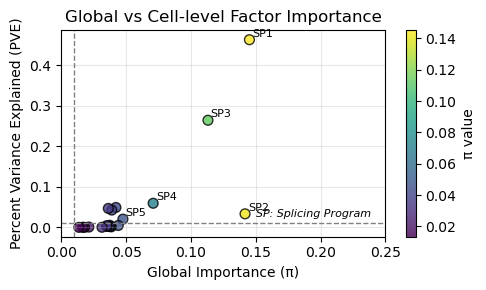

In [12]:
# Simple scatter plot
plt.figure(figsize=(5, 3))

# Use scatter with edgecolors for black outline and c parameter for color mapping
plt.scatter(new_pi, pve_factor_space, s=50, alpha=0.8, 
            c=new_pi, cmap='viridis', edgecolors='black', linewidth=1)

# Add colorbar to show π value mapping
plt.colorbar(label='π value')

# Add factor labels for interesting points
for i in range(len(new_pi)):
    if i < 5 or pve_factor_space[i] > 0.05:  # Label first 3 and high variance factors
        plt.annotate(f'SP{i+1}', (new_pi[i], pve_factor_space[i]), 
                    xytext=(2, 2), textcoords='offset points', fontsize=8)  # Increased from (5,5) to (10,10)

plt.xlabel('Global Importance (π)')
plt.ylabel('Percent Variance Explained (PVE)')
plt.title('Global vs Cell-level Factor Importance')
plt.xlim(0, 0.25)

# add dashed hori line at 0.01
plt.axhline(0.01, color='gray', linestyle='--', linewidth=1)
plt.axvline(0.01, color='gray', linestyle='--', linewidth=1)

# Add SP definition at bottom of plot
plt.text(0.15, 0.02, 'SP: Splicing Program', fontsize=8, style='italic', 
         transform=plt.gca().transData, verticalalignment='bottom')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/factor_pi_vs_pve.pdf


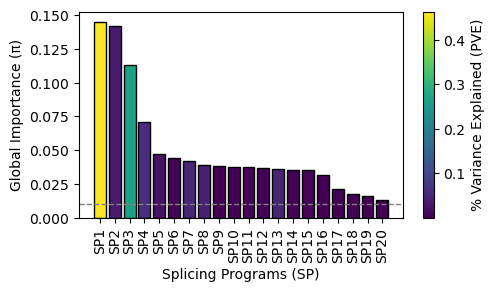

In [13]:
# Assume new_pi and pve_factor_space already exist
num_factors = len(new_pi)
factor_labels = [f'SP{i+1}' for i in range(num_factors)]

# Normalize PVE for colormap
norm = plt.Normalize(pve_factor_space.min(), pve_factor_space.max())
colors = plt.cm.viridis(norm(pve_factor_space))

# Set up figure and axis
fig, ax = plt.subplots(figsize=(5, 3))

# Bar plot
bars = ax.bar(
    factor_labels,
    new_pi,
    color=colors,
    edgecolor='black'
)

# Create scalar mappable and colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # Required dummy
cbar = plt.colorbar(sm, ax=ax)  # Pass ax explicitly
cbar.set_label("% Variance Explained (PVE)")

# Add horizontal threshold line
ax.axhline(0.01, color='gray', linestyle='--', linewidth=1)

# Formatting
ax.set_ylabel('Global Importance (π)')
ax.set_xlabel('Splicing Programs (SP)')
# ax.set_title('Factor Importance (π), colored by PVE')
ax.set_xticks(np.arange(num_factors))
ax.set_xticklabels(factor_labels, rotation=90, fontsize=10)

plt.tight_layout()

# Save to output_dir with today's date OUTPUT_DIR 
output_path = os.path.join(OUTPUT_DIR, f"factor_pi_vs_pve.pdf")
plt.savefig(output_path, format='pdf', bbox_inches='tight')
print(f"Plot saved to: {output_path}")

plt.show()


## Visualize Perplexity

In [14]:
# Step 2: Reindex to match AnnData.obs_names (i.e., cell IDs)
perplexity_df = perplexity_df.reindex(splice_adata.obs_names)

# Step 3: Add as a new column in AnnData.obs
splice_adata.obs["perplexity"] = perplexity_df["perplexity"].values

# Step 4: Filter medium_cell_types with >= 50 cells
valid_medium_ct = (
    splice_adata.obs["medium_cell_type"]
    .value_counts()[lambda x: x >= 50]
    .index
)

# Subset AnnData object to only those cells
splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Ensure ge_adata is subsetted to match
ge_adata = ge_adata[ge_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Assert order of cells is the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [15]:
splice_adata, ge_adata

(AnnData object with n_obs × n_vars = 137893 × 35197
     obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20'
     var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detect

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/perplexity_by_age_rasterized.pdf


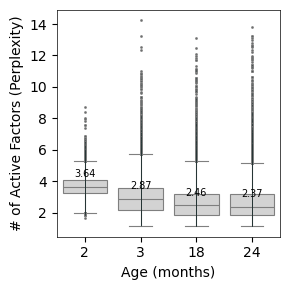

In [16]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("age_numeric", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Age (months)", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_age_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/perplexity_by_sex_rasterized.pdf


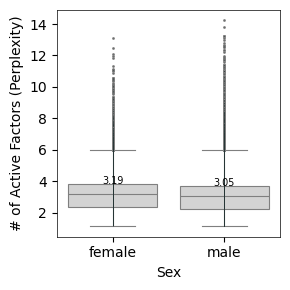

In [17]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=splice_adata.obs,
    x="sex", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="sex", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("sex", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Sex", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_sex_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

In [18]:
splice_adata.obs["medium_cell_type"].value_counts()

medium_cell_type
Cortical excitatory neuron      28335
Inhibitory neuron               15936
Microglia                       12079
B cell                           8640
Skin epithelial cell             7343
Endothelial cell                 7103
Mesenchymal stem cell            4780
Fibroblast                       4623
Hippocampal neuron               3993
T cell                           3588
T cell precursor                 3012
Intestinal epithelial cell       2940
Granulocyte                      2864
Hematopoietic stem cell          2749
Other immune cell                2575
Skeletal muscle cell             2469
Macrophage                       2154
Smooth muscle cell               2056
Pancreatic endocrine cell        1454
Oligodendrocyte                  1334
Monocyte                         1295
Specialized intestinal cell      1290
Immune progenitor                1210
Basal epithelial cell            1149
Urogenital epithelial cell       1014
Epithelial stem cell             

Saved rasterized plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/perplexity_by_cell_type_ordered_rasterized.pdf


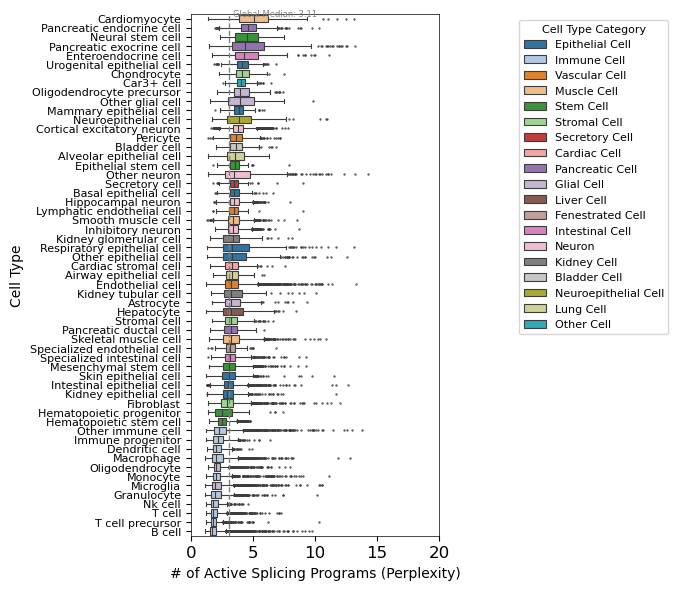

In [19]:
# Step 1: Compute median perplexity by medium_cell_type
median_order = (
    splice_adata.obs
    .groupby("medium_cell_type", observed=True)["perplexity"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 2: Color palette for broad_cell_type
unique_broad = splice_adata.obs["broad_cell_type"].unique()
palette = sns.color_palette("tab20", len(unique_broad))
palette_dict = dict(zip(unique_broad, palette))

# Step 3: Start figure
fig, ax = plt.subplots(figsize=(8, 6))

# Step 4: Main plot
bp = sns.boxplot(
    data=splice_adata.obs,
    y="medium_cell_type", 
    x="perplexity", 
    hue="broad_cell_type", 
    fliersize=0.6, 
    linewidth=0.8,
    order=median_order,
    palette=palette_dict,
    ax=ax
)

# Rasterize fliers
for c in ax.collections:
    if isinstance(c, plt.collections.PathCollection):
        c.set_rasterized(True)

# Global median line
global_median = splice_adata.obs["perplexity"].median()
ax.axvline(global_median, color='gray', linestyle='--', linewidth=1)
ax.text(global_median + 0.3, -1, f"Global Median: {global_median:.2f}",
        color='gray', fontsize=6, va='top')

# Legend
ax.legend(
    title="Cell Type Category",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=8,
    frameon=True
)

# Axis formatting
ax.set_ylabel("Cell Type", fontsize=10)
ax.set_xlabel("# of Active Splicing Programs (Perplexity)", fontsize=10)
ax.set_xticks(np.arange(0, 25, 5))
ax.set_xticklabels(np.arange(0, 25, 5), fontsize=12)
ax.tick_params(axis='y', labelsize=8)  # ⬅️ Smaller font for cell type labels

# Border
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Save
plt.tight_layout()
pdf_path = f"{OUTPUT_DIR}/perplexity_by_cell_type_ordered_rasterized.pdf"
plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Saved rasterized plot to: {pdf_path}")
plt.show()

In [20]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")
import utils  # or: from utils import your_function
import importlib
importlib.reload(utils)

<module 'utils' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/utils.py'>

## Get correlation matrix plot

In [21]:
# Remake PHI matrix correlation plot
X_PHI_corr_matrix = plot_correlation_matrix(splice_adata.obsm["X_PHI"], OUTPUT_DIR)

Saved correlation matrix to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/correlation_matrix_PHI.pdf


## More detailed aging analysis

### Figure 2 Factor Covaraites Labels

In [22]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

def run_variance_explained_analysis(
    splice_adata, 
    sample_id,
    cell_type_col,
    PLOTS_DIR=None, 
    DATA_DIR=None,
    f_display_mode="log10",       # "raw", "log10", "zscore_by_term"
    f_clip_percentile=99,         # upper clip for F visualization
    plot_prop=True,               # plot PropSS heatmap
    plot_F=True                   # plot F-stat heatmap
):
    """
    Variance attribution for splicing programs (LeafletFA factors).

    Steps:
      1) Z-score factors (columns) to remove scale bias.
      2) OLS per factor with Type-II ANOVA:
           SP_k ~ C(cell_type) + C(tissue) + C(sex) + age + C(dataset)
                   + C(cell_type):age + C(sex):age
      3) Plot:
         (A) Proportion of explained variance (sum_sq share) per factor×term
         (B) F-statistic heatmap, with display modes:
              - "raw": clipped raw F
              - "log10": log10(F+1) then clip
              - "zscore_by_term": column-wise z-score of F
         Both use identical row order (from PropSS clustering if available).
    Returns:
      dict with raw/processed tables and row order used for plotting.
    """
    print("Running variance explained analysis...")

    # ---------- Build analysis frame with z-scored factors ----------
    X_phi = splice_adata.obsm["X_PHI"]
    X_phi_z = StandardScaler(with_mean=True, with_std=True).fit_transform(X_phi)
    factor_names = [f"SP_{i+1}" for i in range(X_phi_z.shape[1])]
    analysis_df = pd.DataFrame(X_phi_z, index=splice_adata.obs_names, columns=factor_names)

    # Covariates
    obs_cols_to_copy = {
        cell_type_col: "cell_type",
        "tissue": "tissue",
        "sex": "sex",
        sample_id: "dataset",
        "age_numeric": "age",
    }
    for obs_col, df_col in obs_cols_to_copy.items():
        analysis_df[df_col] = splice_adata.obs[obs_col].values

    # ---------- Model terms ----------
    base_terms = ['C(cell_type)', 'C(tissue)', 'C(sex)', 'age', 'C(dataset)']
    interaction_terms = ['C(cell_type):age', 'C(sex):age']
    all_terms = base_terms + interaction_terms

    # ---------- Fit OLS + ANOVA per factor ----------
    r2_records, anova_tables = [], []
    for factor_col in tqdm(factor_names, desc="Analyzing factors for variance explained"):
        formula = f"{factor_col} ~ " + " + ".join(all_terms)
        model = smf.ols(formula, data=analysis_df, missing='drop').fit()
        if model.nobs < (model.df_model + 2) or model.df_resid <= 0:
            print(f"Skipping {factor_col}: insufficient observations")
            continue
        r2_records.append({'SP': factor_col, 'r2_overall': model.rsquared, 'n_obs': int(model.nobs)})
        a2 = anova_lm(model, typ=2)
        a2['SP'] = factor_col
        anova_tables.append(a2.reset_index())

    r2_df = pd.DataFrame(r2_records)
    anova_df = pd.concat(anova_tables, ignore_index=True)

    # ---------- Clean & ensure numeric ----------
    anova_df = anova_df.rename(columns={'index': 'covariate_term'})
    anova_df = anova_df[anova_df['covariate_term'] != 'Residual'].copy()
    for col in ['sum_sq', 'F']:
        anova_df[col] = pd.to_numeric(anova_df[col], errors='coerce')

    # ---------- (A) Proportion of explained variance (PropSS) ----------
    ss_pivot = anova_df.pivot_table(index='SP', columns='covariate_term', values='sum_sq', aggfunc='sum')
    ss_pivot = ss_pivot.loc[:, (ss_pivot.sum(axis=0).abs() > 1e-12)]
    total_ss = ss_pivot.sum(axis=1)
    prop_var = ss_pivot.div(total_ss.replace(0, np.nan), axis=0)

    # Row labels with R^2
    r2_map = (
        r2_df.set_index('SP')
            .loc[prop_var.index]
            .assign(row=lambda d: [f"{sp} (R²={r2:.2f})" for sp, r2 in zip(d.index, d['r2_overall'])])
            ['row'].to_dict()
    )
    prop_var_disp = prop_var.rename(index=r2_map).astype(float)

    # ---------- (B) F-statistic processing ----------
    f_pivot = anova_df.pivot_table(index='SP', columns='covariate_term', values='F', aggfunc='mean')
    f_pivot = f_pivot.reindex(prop_var.index)  # align to PropSS row order

    F_vis = f_pivot.replace([np.inf, -np.inf], np.nan).copy()
    cbar_label = ""
    cmap = "viridis"; vmin = None; vmax = None

    if f_display_mode == "log10":
        F_vis = np.log10(F_vis + 1.0)
        cbar_label = "log₁₀(F + 1)"
        clip_hi = np.nanpercentile(F_vis.values.ravel(), f_clip_percentile) if np.isfinite(F_vis.values).any() else None
        if clip_hi and clip_hi > 0:
            F_vis = F_vis.clip(upper=clip_hi)
        vmin, vmax = 0, clip_hi
    elif f_display_mode == "zscore_by_term":
        # column-wise z-score
        F_vis = (F_vis - F_vis.mean(axis=0)) / F_vis.std(axis=0)
        cbar_label = "F (z-score within term)"
        clip_hi = np.nanpercentile(F_vis.values.ravel(), f_clip_percentile)
        clip_lo = np.nanpercentile(F_vis.values.ravel(), 100 - f_clip_percentile)
        F_vis = F_vis.clip(lower=clip_lo, upper=clip_hi)
        cmap = "PRGn"
        vmin, vmax = None, None
    else:  # "raw"
        cbar_label = "F-statistic (clipped)"
        clip_hi = np.nanpercentile(F_vis.values.ravel(), f_clip_percentile) if np.isfinite(F_vis.values).any() else None
        if clip_hi and clip_hi > 0:
            F_vis = F_vis.clip(upper=clip_hi)
        cmap = "viridis"
        vmin, vmax = 0, clip_hi

    F_disp = F_vis.rename(index=r2_map).astype(float)

    # ---------- Plot A: PropSS ----------
    cg_prop = None
    if plot_prop:
        width, height = 5.0, 4.0
        annot_prop = prop_var_disp.round(2).astype(str)
        cg_prop = sns.clustermap(
            prop_var_disp, cmap="PRGn", center=0,
            linewidths=0.2, linecolor='black',
            annot=annot_prop, fmt='',
            annot_kws={"size": 4, "color": "grey"},
            figsize=(width, height),
            xticklabels=True, yticklabels=True,
            vmin=0, vmax=1.0
        )
        plt.setp(cg_prop.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        plt.setp(cg_prop.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
        cg_prop.ax_heatmap.set_xlabel('Covariate Terms', fontsize=11, fontweight='bold')
        cg_prop.ax_heatmap.set_ylabel('LeafletFA Splicing Programs', fontsize=11, fontweight='bold')
        if PLOTS_DIR:
            out_prop = os.path.join(PLOTS_DIR, f"variance_explained_propSS_{cell_type_col}.pdf")
            cg_prop.savefig(out_prop, format="pdf", bbox_inches="tight")
            print(f"  Saved: {out_prop}")

    # ---------- Plot B: F-stat ----------
    if plot_F:
        # keep same row order as PropSS if we clustered it
        if cg_prop is not None and cg_prop.dendrogram_row is not None:
            row_idx = cg_prop.dendrogram_row.reordered_ind
            F_disp_ordered = F_disp.iloc[row_idx]
        else:
            F_disp_ordered = F_disp

        # sparse annotations: only show top 5% values for readability (for log/raw modes)
        if f_display_mode in ("raw", "log10"):
            thresh = np.nanpercentile(F_disp_ordered.values.ravel(), 95)
            annot_F = F_disp_ordered.where(F_disp_ordered >= thresh).round(2).astype(str)
        else:
            annot_F = F_disp_ordered.round(2).astype(str)

        cg_F = sns.clustermap(
            F_disp_ordered,
            cmap=cmap,
            linewidths=0.2, linecolor='black',
            annot=annot_F, fmt='',
            annot_kws={"size": 4},
            figsize=(5, 4),
            xticklabels=True, yticklabels=True,
            col_cluster=True, row_cluster=(cg_prop is None),
            vmin=vmin, vmax=vmax
        )
        plt.setp(cg_F.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        plt.setp(cg_F.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
        cg_F.ax_heatmap.set_xlabel('Covariate Terms', fontsize=11, fontweight='bold')
        cg_F.ax_heatmap.set_ylabel('LeafletFA Splicing Programs', fontsize=11, fontweight='bold')
        cbar = cg_F.ax_heatmap.collections[0].colorbar
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label(cbar_label, fontsize=9)
        if PLOTS_DIR:
            out_F = os.path.join(PLOTS_DIR, f"variance_explained_Fstat_{f_display_mode}_{cell_type_col}.pdf")
            cg_F.savefig(out_F, format="pdf", bbox_inches="tight")
            print(f"  Saved: {out_F}")

    plt.show()

    return {
        "anova_raw": anova_df,           # long-form ANOVA table (no residual)
        "prop_var": prop_var,            # proportions per factor × term
        "F_raw": f_pivot,                # raw (unclipped) F values
        "prop_var_display": prop_var_disp,
        "F_display": F_disp,             # processed for visualization
        "r2": r2_df
    }

Running variance explained analysis...


Analyzing factors for variance explained: 100%|██████████| 20/20 [02:11<00:00,  6.59s/it]


  Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/variance_explained_propSS_medium_cell_type.pdf
  Saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/variance_explained_Fstat_log10_medium_cell_type.pdf


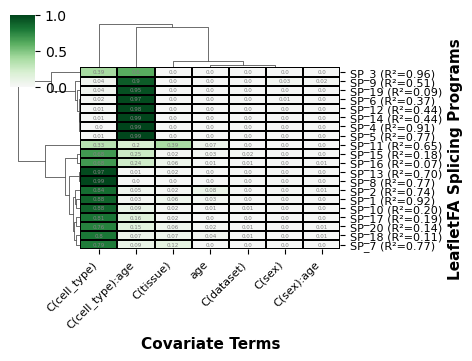

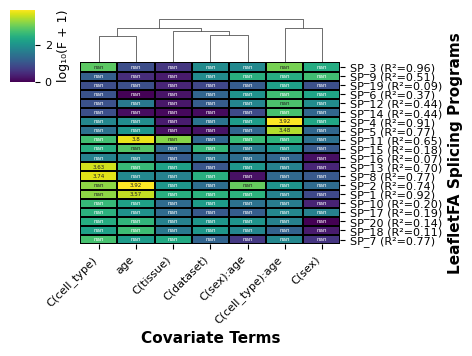

In [23]:
# read in factor labels 
factor_labels_medium_cell_type = run_variance_explained_analysis(splice_adata, cell_type_col="medium_cell_type", sample_id="dataset", PLOTS_DIR=OUTPUT_DIR)

In [24]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")
import figure_plotting
import importlib
importlib.reload(figure_plotting)

<module 'figure_plotting' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/figure_plotting.py'>

### Subset aging dataset

In [25]:
# subset to cells with age > 2 and at least 100 young and 100 old cells
splice_adata_full = splice_adata.copy()

# filter to cells with age > 2
splice_adata = splice_adata[splice_adata.obs["age_numeric"] > 2].copy()
counts = splice_adata.obs.groupby(["medium_cell_type", "age_group"]).size().unstack(fill_value=0)
eligible_ct = counts.index[(counts["young"] >= 100) & (counts["old"] >= 100)]

# Apply filter
splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(eligible_ct)].copy()
print(f"Number of cell types after filtering: {len(splice_adata.obs['medium_cell_type'].unique())}")
print(f"Number of cells after filtering: {splice_adata.n_obs}")

ge_adata_full = ge_adata.copy()
ge_adata = ge_adata[splice_adata.obs_names].copy()
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

Number of cell types after filtering: 35
Number of cells after filtering: 84047



Top 2 positively correlated factor pairs:
factor_i factor_j      rho
     SP8     SP13 0.566261
     SP1      SP7 0.563102

Top 2 negatively correlated factor pairs:
factor_i factor_j       rho
    SP14     SP15 -0.311977
    SP14     SP17 -0.291739

Top 2 least correlated factor pairs:
factor_i factor_j       rho
     SP9     SP12 -0.003205
    SP16     SP18  0.004100


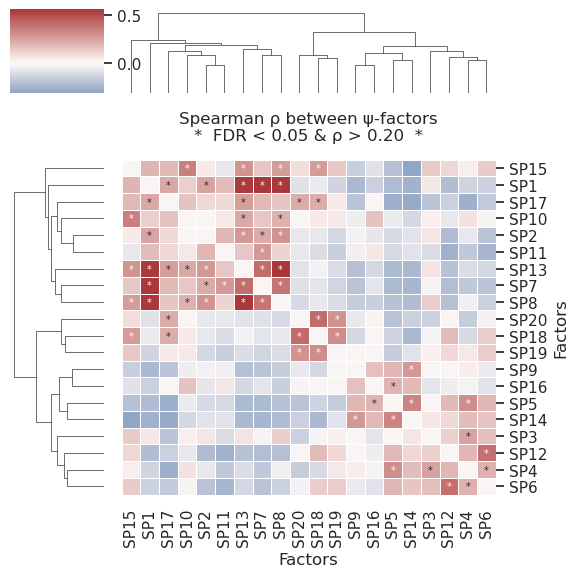

In [26]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests   # pip install statsmodels

# ── 1.  Data → DataFrame ───────────────────────────────────────────────────────
ψ  = splice_adata.varm["psi_learned"]          # (J, K)
K  = ψ.shape[1]

# Subtract row (junction) mean from each factor value
ψ_centered = ψ - np.nanmean(ψ, axis=1, keepdims=True)
K = ψ_centered.shape[1]
df = pd.DataFrame(ψ_centered, columns=[f"SP{j+1}" for j in range(K)])

# ── 2.  ρ and p-values for *each* pair ─────────────────────────────────────────
rho    = np.zeros((K, K))
pvals  = np.ones((K, K))

for i in range(K):
    for j in range(i+1, K):
        r, p = spearmanr(df.iloc[:, i], df.iloc[:, j], nan_policy='omit')
        rho[i, j] = rho[j, i] = r
        pvals[i, j] = pvals[j, i] = p

# ── 3.  Benjamini–Hochberg FDR adjustment over the upper triangle ─────────────
tri_idx         = np.triu_indices(K, k=1)          # exclude the diagonal
p_flat          = pvals[tri_idx]
_, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
qvals           = np.ones_like(pvals)
qvals[tri_idx]  = qvals.T[tri_idx] = q_flat

# ── 4.  Significance mask  (FDR < 0.05 and ρ > 0.20) ──────────────────────────
star_mask = (qvals < 0.05) & (rho > 0.20)
annot     = np.where(star_mask, "*", "")

# ── 5.  Build DataFrames with indices/columns for seaborn ─────────────────────
rho_df   = pd.DataFrame(rho,   index=df.columns, columns=df.columns)
annot_df = pd.DataFrame(annot, index=df.columns, columns=df.columns)


# ── 1.  clustered heat-map with all tick labels ───────────────────────────────
sns.set_theme(style="white")
g = sns.clustermap(
    rho_df,
    cmap="vlag", center=0, linewidths=0.4, square=True,
    metric="euclidean", row_cluster=True, col_cluster=True,
    figsize=(6, 6),
    annot=annot_df, fmt="", annot_kws={"size":7},
    xticklabels=True, yticklabels=True
)

# Rotate x-labels so they don’t overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.ax_heatmap.set_title("Spearman ρ between ψ-factors\n*  FDR < 0.05 & ρ > 0.20  *", pad=14)
g.ax_heatmap.set_xlabel("Factors")
g.ax_heatmap.set_ylabel("Factors")

plt.tight_layout()

# ── 2.  save to disk ──────────────────────────────────────────────────────────
g.savefig(f"{OUTPUT_DIR}/psi_factor_spearman_clustermap.pdf", bbox_inches="tight")

# ── 3.  report extreme pairs ──────────────────────────────────────────────────
# flatten upper triangle (exclude diagonal), keep finite values only
tri_i, tri_j = np.triu_indices_from(rho_df, k=1)
tri_vals = rho_df.values[tri_i, tri_j]

# build a DataFrame for easy sorting
pairs_df = pd.DataFrame({
    "factor_i": rho_df.index[tri_i],
    "factor_j": rho_df.columns[tri_j],
    "rho":      tri_vals
}).dropna()

# top 2 positive
top_pos = pairs_df.nlargest(2, "rho")
# top 2 negative
top_neg = pairs_df.nsmallest(2, "rho")
# top 2 least correlated (closest to zero)
top_flat = pairs_df.iloc[(pairs_df["rho"].abs()).nsmallest(2).index]

print("\nTop 2 positively correlated factor pairs:")
print(top_pos.to_string(index=False))

print("\nTop 2 negatively correlated factor pairs:")
print(top_neg.to_string(index=False))

print("\nTop 2 least correlated factor pairs:")
print(top_flat.to_string(index=False))


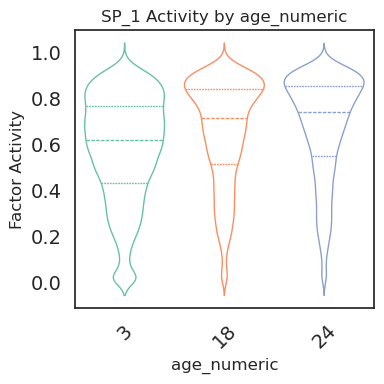

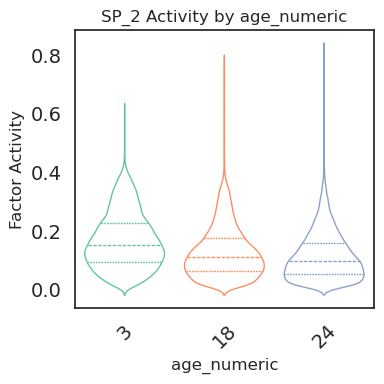

In [27]:
plot_factor_violin(
    adata=splice_adata,
    factor_list=["SP_1", "SP_2"],
    groupby="age_numeric",
    save_prefix="factor_age_violin"
)

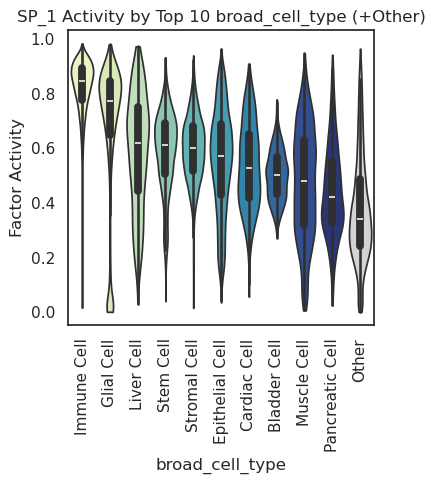

In [28]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_1"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

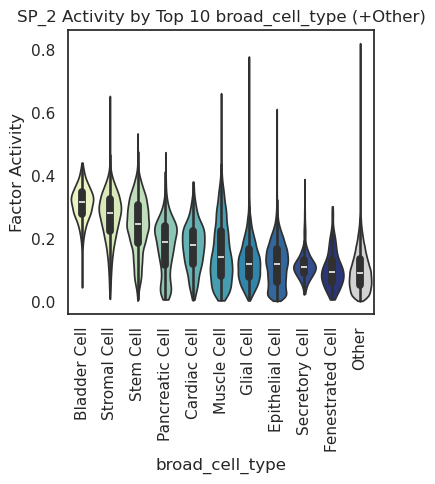

In [29]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_2"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

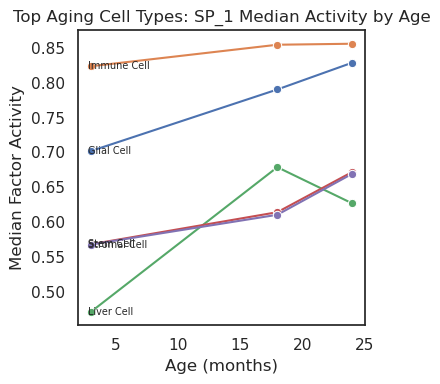

In [30]:
plot_factor_age_trends(
    df=splice_adata.obs[splice_adata.obs["age_numeric"] > 2],
    factor="SP_1",
    top_n=5,
    title_prefix="Top Aging Cell Types",
    save_path=f"{OUTPUT_DIR}/Factor_1_age_trend_top3.pdf"
)


### Get heatmap for common cell types 

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/clustering_common_celltype_dataset_factors.pdf


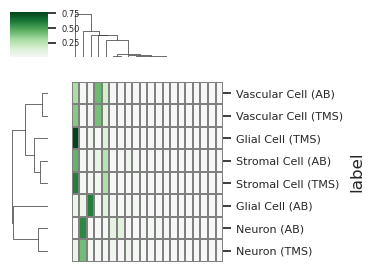

In [31]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = splice_adata_full.obs.groupby(['broad_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["AB"] > 0) & (cell_type_counts["TMS"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()

# Subset to common cell types
adata_common = splice_adata_full[
    splice_adata_full.obs["broad_cell_type"].isin(common_cell_type_names)
].copy()

# Convert to categorical first
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].astype("category")
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].cat.remove_unused_categories()

# Extract factor matrix and build DataFrame
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i+1}" for i in range(num_factors)]

df = adata_common.obs[["broad_cell_type", "dataset"]].copy()
for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

# Compute median factor values by cell type and dataset
median_profiles = (
    df.groupby(["broad_cell_type", "dataset"], observed=True)[factor_cols]
    .median()
    .reset_index()
)

# Create composite labels
median_profiles["label"] = (
    median_profiles["broad_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

# Set label as index
median_profiles = median_profiles.set_index("label")[factor_cols]

# Plot clustermap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(4, 3)
)

# Remove x-axis tick labels (factors)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xticklabels([])

# Format y-axis (cell types)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)

# Colorbar label and tick font
g.ax_cbar.set_label("Median Factor Activity")
g.ax_cbar.yaxis.label.set_size(7)
g.ax_cbar.tick_params(labelsize=6)

# Save
plt.tight_layout()
g.savefig(f"{OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf", bbox_inches='tight')
print(f"Saved plot to {OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf")
plt.show()

In [32]:
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].astype("category")
splice_adata.obs["medium_cell_type"] = splice_adata.obs["medium_cell_type"].astype("category")

  broad_cell_type age_numeric      SP_4
0          Neuron           3  0.049095
1          Neuron          18  0.022933
2          Neuron          24  0.023437


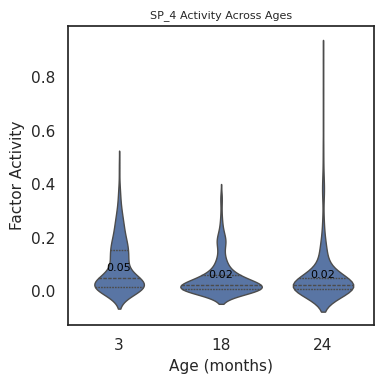

In [33]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="SP_4",
    cell_types=["Neuron"],
    figsize=(4, 4), save_path=f"{OUTPUT_DIR}/F10_SecretoryCells.pdf"
)


  broad_cell_type age_numeric      SP_4
0          Neuron           3  0.049095
1          Neuron          18  0.022933
2          Neuron          24  0.023437


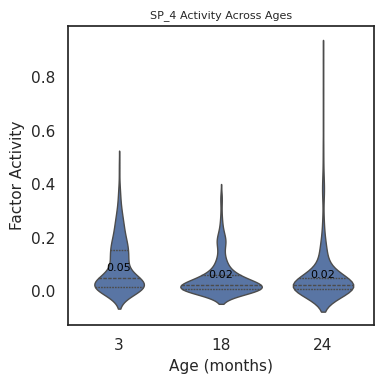

In [34]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="SP_4",
    cell_types=["Neuron"],
    figsize=(4, 4), save_path=f"{OUTPUT_DIR}/F10_SecretoryCells.pdf"
)


## Look at sig junctions from differential splicing analysis

In [35]:
# Run the analysis
print("="*60)
print("TOP JUNCTIONS PER FACTOR PSI ANALYSIS")
print("="*60)

# Step 1: Get top junctions per factor
top_junctions_dict, subset_splice_adata, junction_factor_map = get_top_junctions_per_factor(
    diff_spl, 
    splice_adata, 
    top_n=10, 
    effect_size_col='abs_effect_size'
)

# Get unique junction indices
unique_junctions = junction_factor_map['junction_idx'].unique()

# Extract PSI learned values for these junctions
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]

TOP JUNCTIONS PER FACTOR PSI ANALYSIS
Getting top 10 junctions per factor...
Ranking by: abs_effect_size
Found 20 factors: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Factor 0: 10 junctions, effect size range: 0.961 - 0.991
Factor 1: 10 junctions, effect size range: 0.851 - 0.916
Factor 2: 10 junctions, effect size range: 0.782 - 0.905
Factor 3: 10 junctions, effect size range: 0.907 - 0.959
Factor 4: 10 junctions, effect size range: 0.920 - 0.966
Factor 5: 10 junctions, effect size range: 0.894 - 0.953
Factor 6: 10 junctions, effect size range: 0.979 - 0.997
Factor 7: 10 junctions, effect size range: 0.971 - 0.990
Factor 8: 10 junctions, effect size range: 0.915 - 0.974
Factor 9: 10 junctions, effect size range: 0.798 - 0.913
Factor 10: 10 junctions, effect size range: 0.943 - 0.985
Factor 11: 10 junctions, effect size range: 0.910 - 0.969
Factor 12: 10 junctions, effect size range: 0.937 - 0.989
Factor 13: 10 junctions, effect size range: 0.891 - 0.921
Fact

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/psi_clustermap_top_10.pdf


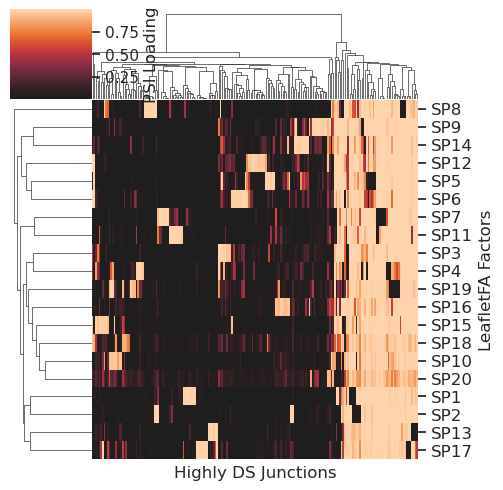

In [36]:
# 1. Map row labels: get junction_id or gene_name from .var
# Get the integer indices into .varm (which uses original order)
unique_junctions = junction_factor_map['junction_idx'].unique()
# psi_learned: shape (n_junctions, n_factors), so index using integer indices
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]
junction_id = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["junction_id"].values
gene_name = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["gene_name"].values

# Get number of factors (rows after transpose)
num_factors = psi_subset.shape[1]

# Create factor labels: F1, F2, ..., FK
factor_labels = [f"SP{i+1}" for i in range(num_factors)]

# 2. Create clustermap with color tweaks
g = sns.clustermap(
    psi_subset.T,
    center=0,
    figsize=(6, 5),
    xticklabels=False,
    yticklabels=factor_labels,
    cbar_kws={'label': 'PSI Loading'},
    robust=True  # clip extreme values for better contrast
)

# 3. Style adjustments
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)
g.ax_heatmap.set_ylabel("LeafletFA Factors")
g.ax_heatmap.set_xlabel("Highly DS Junctions")
plt.subplots_adjust(left=0.3, bottom=0.05, top=0.95, right=0.98)
save_path = os.path.join(OUTPUT_DIR, "psi_clustermap_top_10.pdf")
g.savefig(save_path, bbox_inches="tight")
print(f"Saved plot to {save_path}")
plt.show()

## Get UMAP on X_PHI

In [37]:
ge_adata.layers["scVI_linear"] = ge_adata.obsm["X_normalized_scVI_linear"]

In [38]:
# Run neighbors and UMAP on X_PHI embedding
# sc.pp.neighbors(filtered_splice_adata, use_rep="X_PHI", n_neighbors=8)
# sc.tl.umap(filtered_splice_adata, random_state=0, min_dist=0.3)

In [39]:
#plot_gene_and_factor_umap_from_phi(
#    splice_adata=filtered_splice_adata,
#    ge_adata=filtered_ge_adata,
#    gene_name="ZWINT",
#    factor_name="Factor_2",
#    groupby="broad_cell_type",
#    group_level="Microglia"
#)

In [40]:
ge_adata.obs["SP_1"] = splice_adata.obs["SP_1"]
ge_adata.obs["SP_2"] = splice_adata.obs["SP_2"]

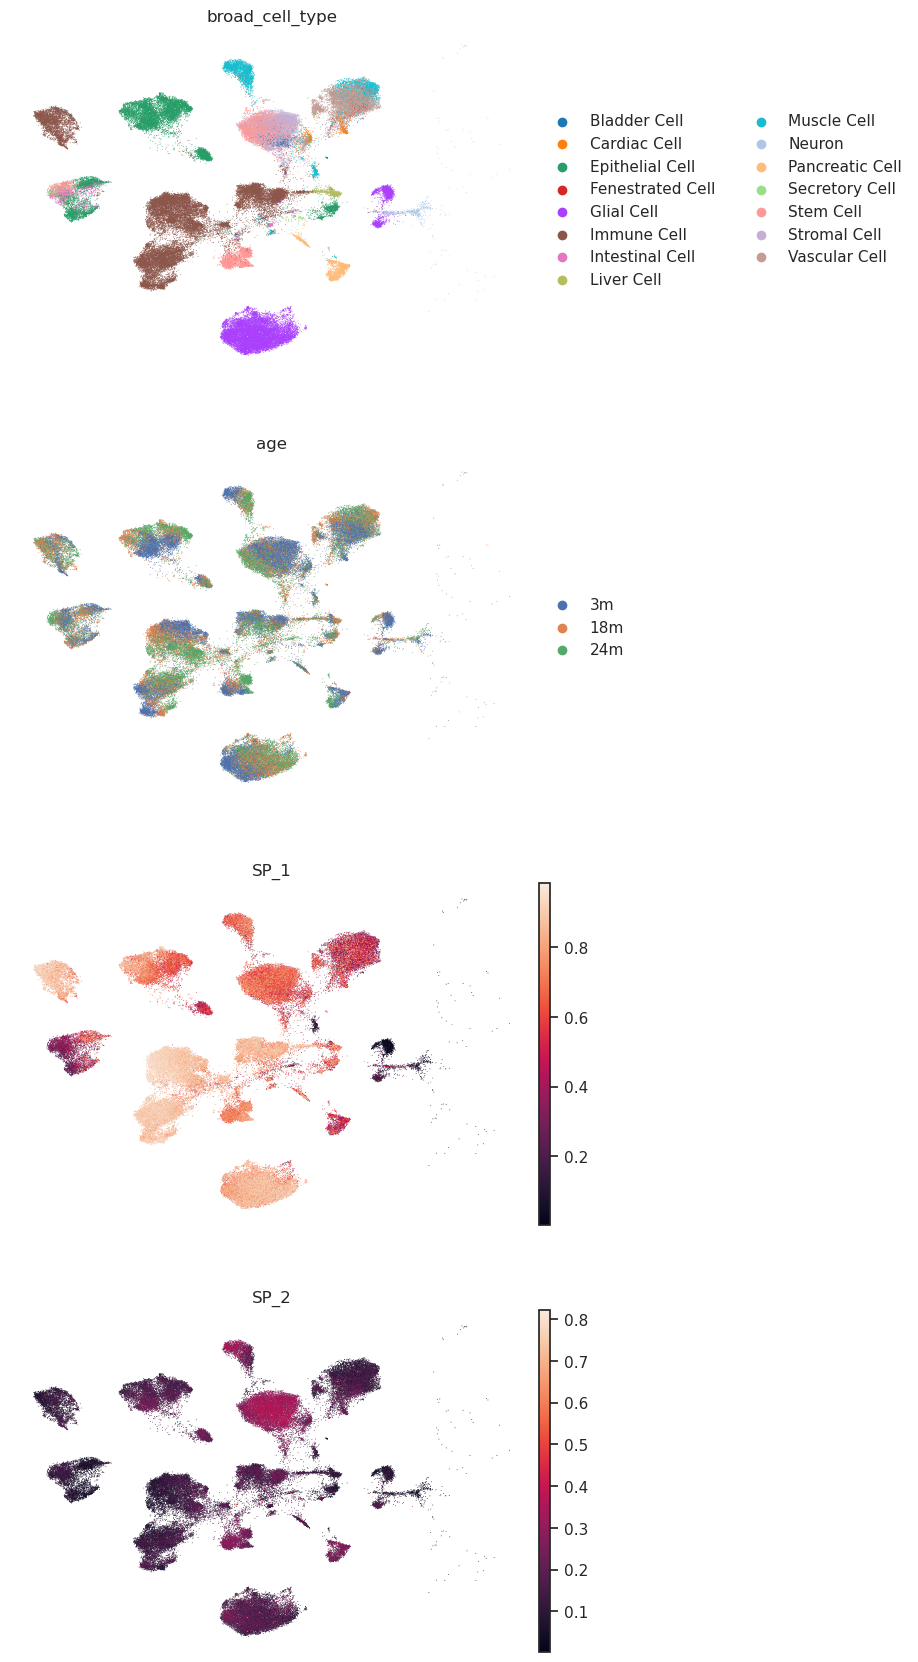

In [41]:
# Multiple plots in one figure
sc.pl.umap(ge_adata, 
           color=['broad_cell_type', 'age', 'SP_1', 'SP_2'],
           ncols=1,
           frameon=False,
           save='_multiplot.pdf')

### New circle heatmap combining delta age and activity across cell types

In [42]:
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Circle, Rectangle
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_factor_circles(adata, cell_type_col='broad_cell_type', age_col='age_group'):
    """
    Clustered tile plot: background color shows delta PSI (old - young),
    circle outlines show activity (median nonzero expression).
    """
    # Extract factor matrix
    X_PHI = adata.obsm["X_PHI"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"SP_{i+1}" for i in range(n_factors)]
    factor_df = pd.DataFrame(X_PHI, index=adata.obs.index, columns=factor_cols)

    # Median expression (non-zero) per cell type
    median_expr = pd.DataFrame(index=adata.obs[cell_type_col].unique(), columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        ct_data = factor_df.loc[ct_mask]
        for factor in factor_cols:
            vals = ct_data[factor]
            nonzero = vals[vals > 0]
            median_expr.loc[ct, factor] = nonzero.median() if len(nonzero) > 0 else 0
    median_expr = median_expr.astype(float).fillna(0)

    # Delta PSI: old - young
    delta_age = pd.DataFrame(index=median_expr.index, columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        old_mask = ct_mask & (adata.obs[age_col] == 'old')
        young_mask = ct_mask & (adata.obs[age_col] == 'young')
        if old_mask.sum() > 10 and young_mask.sum() > 10:
            for factor in factor_cols:
                old_vals = factor_df.loc[old_mask, factor]
                young_vals = factor_df.loc[young_mask, factor]
                delta_age.loc[ct, factor] = old_vals.median() - young_vals.median()
        else:
            delta_age.loc[ct] = 0
    delta_age = delta_age.astype(float).fillna(0)

    # Clustering
    factor_order = list(range(len(factor_cols)))  # preserve original SP_1 ... SP_K order
    celltype_order = dendrogram(linkage(median_expr, method='ward'), no_plot=True)['leaves']
    celltype_order = [median_expr.index[i] for i in celltype_order]

    # Compute cell counts
    celltype_counts = adata.obs[cell_type_col].value_counts()
    celltype_labels = [f"{ct} ({celltype_counts[ct]})" for ct in celltype_order]

    # Reorder matrices
    median_ordered = median_expr.loc[celltype_order, :].iloc[:, factor_order]
    delta_ordered = delta_age.loc[celltype_order, :].iloc[:, factor_order]

    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 7))
    n_cells = len(median_ordered)
    n_factors = len(median_ordered.columns)
    ax.set_xlim(-0.5, n_factors - 0.5)
    ax.set_ylim(-0.5, n_cells - 0.5)

    # Color scale for delta PSI
    cmap = plt.cm.BrBG
    vmax = max(abs(delta_ordered.values.min()), abs(delta_ordered.values.max()))
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)

    # Draw tiles
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            delta = delta_ordered.loc[cell_type, factor]
            color = cmap(norm(delta))
            tile = Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='none')
            ax.add_patch(tile)

    # Draw circle outlines for activity
    min_radius = 0.1
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            expr = median_ordered.loc[cell_type, factor]
            if expr > 0.001:
                radius = max(min_radius, (np.log10(expr + 0.01) + 2) * 0.15)
                delta = delta_ordered.loc[cell_type, factor]
                color = cmap(norm(delta))  # match background
                circle = Circle((j, i), radius, facecolor=color, edgecolor='black', linewidth=0.4)
                ax.add_patch(circle)

    # Axis labels
    ax.set_xticks(range(n_factors))
    ax.set_xticklabels(median_ordered.columns, rotation=90, fontsize=10)
    ax.set_yticks(range(n_cells))
    ax.set_yticklabels(celltype_labels, fontsize=10)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False)
    ax.grid(False)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Δ SP Activity (old - young)', shrink=0.3)

    from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox, VPacker, HPacker, TextArea

    # Legend values (representative activity levels)
    example_exprs = [0.01, 0.1, 1.0]

    # Function to compute radius in axis units
    def compute_radius(val):
        return max(min_radius, (np.log10(val + 0.01) + 2) * 0.15)

    # Build legend items
    legend_items = []
    for val in example_exprs:
        radius = compute_radius(val)

        # Circle scaled correctly in data units
        circle_box = AuxTransformBox(ax.transData)
        circle = Circle((0, 0), radius, facecolor='white', edgecolor='black', linewidth=0.6)
        circle_box.add_artist(circle)

        # Label
        label = TextArea(f"{val:.2f}", textprops=dict(fontsize=8, va='center', ha='left'))

        # Combine horizontally: [circle | label]
        item = HPacker(children=[circle_box, label], align="center", pad=0, sep=5)
        legend_items.append(item)

    # Combine all items vertically
    legend_box = VPacker(children=legend_items, align="left", pad=0, sep=6)

    # Place the anchored box
    anchored_legend = AnchoredOffsetbox(
        loc='upper right',
        child=legend_box,
        frameon=True,
        bbox_to_anchor=(1.25, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0.5,
        pad=0.5
    )
    ax.add_artist(anchored_legend)

    plt.tight_layout()
    return fig

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/delta_median_old_minus_young_by_broad_cell_type_dot_heatmap.pdf


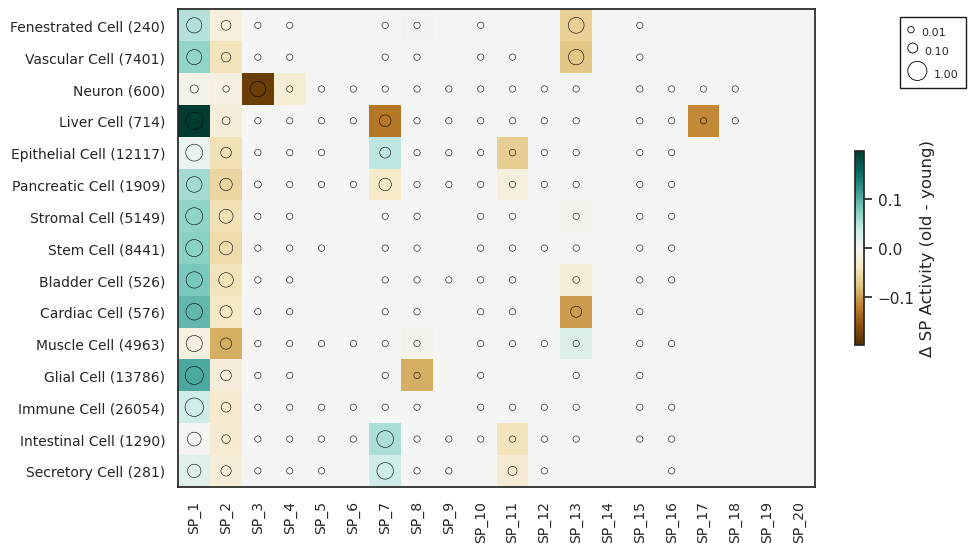

In [43]:
cell_type_col = "broad_cell_type"
fig = plot_factor_circles(splice_adata, cell_type_col=cell_type_col)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/delta_median_old_minus_young_by_medium_cell_type_dot_heatmap.pdf


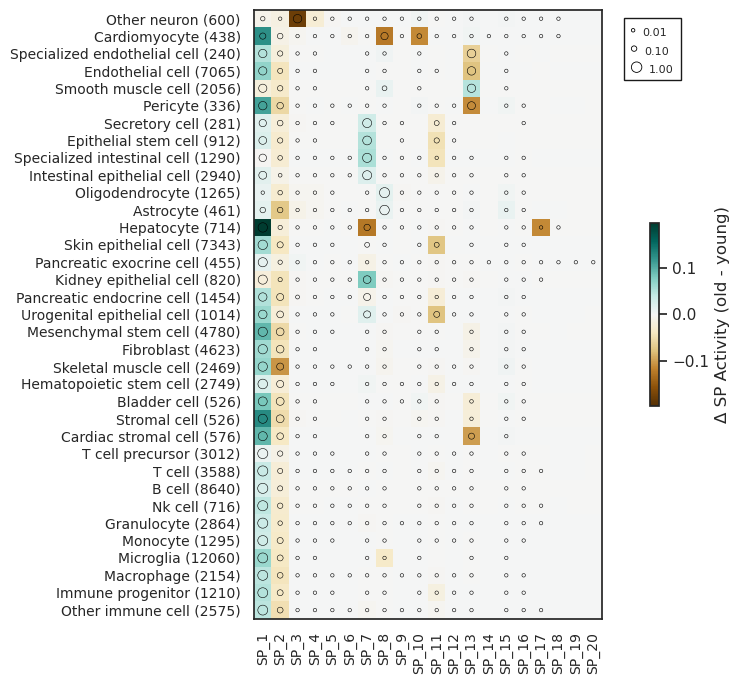

In [44]:
cell_type_col = "medium_cell_type"
fig = plot_factor_circles(splice_adata, cell_type_col=cell_type_col)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

In [45]:
def plot_factor_junction_annotation_counts(final_df, output_path):
    """
    Create a stacked barplot showing the number of significant junctions per factor,
    colored by junction annotation category.
    """
    # Count unique junctions by (factor, annotation)
    counts = (
        final_df.groupby(["factor_idx", "junction_annotation"])["junction_id_index"]
        .nunique()
        .reset_index(name="count")
    )
    # Add factor name column
    counts["factor_name"] = "SP_" + (counts["factor_idx"] +1).astype(str)
    # Pivot to wide format: rows=factor_name, columns=annotation, values=count
    pivot_df = counts.pivot(index="factor_name", columns="junction_annotation", values="count").fillna(0)
    # print table
    print(pivot_df)
    # Sort by total number of junctions
    pivot_df["total"] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values("total", ascending=False)
    pivot_df = pivot_df.drop(columns="total")
    # Plot
    plt.figure(figsize=(5, 3))
    pivot_df.plot(
        kind="bar",
        stacked=True,
        colormap="viridis",  # Or use sns.color_palette("Set2", n_colors=...)
        edgecolor="black"
    )
    plt.xlabel("Splicing Program", fontsize=12)
    plt.ylabel("# of Significant Junctions", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Junction Annotation", fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    # Save
    plt.savefig(output_path, dpi=300)
    print(f"Saved to {output_path}")
    plt.show()
    plt.close()

In [46]:
def plot_junction_factor_distribution(final_df, output_path):
    """Create an improved histogram showing distribution of factors per junction"""
    # Get counts of factors/junction
    junc_counts = final_df.groupby("junction_id_index")["factor_idx"].nunique()
    junc_counts_df = pd.DataFrame({"junction_id_index": junc_counts.index, "num_factors": junc_counts.values})
    # Create figure with appropriate size
    plt.figure(figsize=(5, 4))
    # Create histogram with better styling
    ax = sns.histplot(junc_counts_df["num_factors"], bins=range(1, junc_counts_df["num_factors"].max() + 2), 
                     kde=True, color='steelblue', edgecolor='darkblue', alpha=0.7)
    # Add mean line
    mean_factors = junc_counts_df["num_factors"].mean()
    plt.axvline(mean_factors, color='red', linestyle='--', linewidth=2)
    plt.text(mean_factors + 0.2, plt.ylim()[1]*0.9, f'Mean: {mean_factors:.2f}', 
             color='red', fontweight='bold')
    # Add title and labels with better formatting
    plt.xlabel("# of Splicing Programs with Significant \nEffect on Junction", fontsize=12)
    plt.ylabel("# of junctions", fontsize=12)
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3)
    # increase tick font size 
    # Adjust layout
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    # Save figure with higher DPI
    plt.savefig(output_path, dpi=300)
    print(f"Saved to {output_path}")
    plt.show()
    plt.close()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/differential_splicing_barplot.pdf


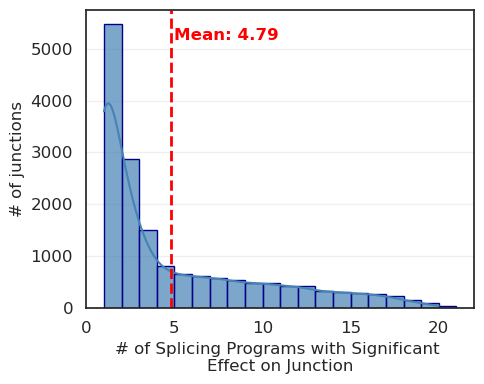

In [47]:
plot_junction_factor_distribution(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_barplot.pdf"))

junction_annotation  3_prime_annotated  5_prime_annotated  Both_SS_annotated  \
factor_name                                                                    
SP_1                             207.0              171.0             5058.0   
SP_10                             90.0               80.0             2006.0   
SP_11                            192.0              197.0             4832.0   
SP_12                            253.0              295.0             4252.0   
SP_13                            162.0              144.0             4025.0   
SP_14                            308.0              311.0             5133.0   
SP_15                            114.0              114.0             3245.0   
SP_16                            117.0              115.0             1929.0   
SP_17                            131.0              115.0             2397.0   
SP_18                             24.0               24.0              617.0   
SP_19                             80.0  

<Figure size 500x300 with 0 Axes>

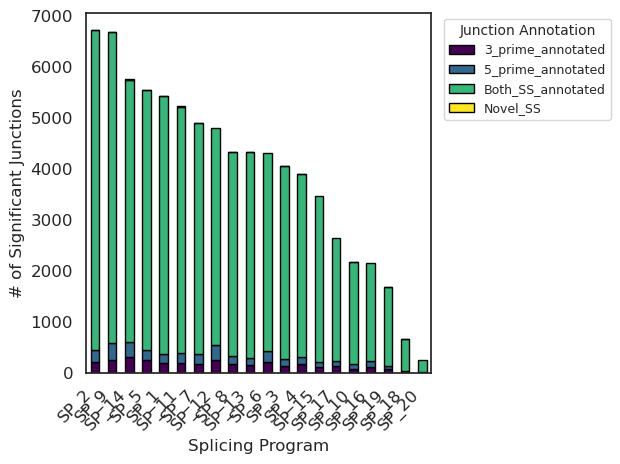

In [48]:
plot_factor_junction_annotation_counts(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_annotation_type_barplot.pdf"))

## Recalculate differential splicing junctions

In [49]:
# Reset junction_id_index column 
psi_samples = leaflet_model["psi_samples"]
splice_adata.var["junction_id_index"] = np.arange(splice_adata.n_vars)
print("\n>> Running analysis functions...")
results = ds.analyze_all_factors_psi(psi_samples, top_junctions=splice_adata.var["junction_id_index"].values, min_effect_size=0.2)
all_results = []

for factor_idx, (effect_size_list, significance_df) in results.items():
    # Append to list
    all_results.append(significance_df)
    print("\n>> Running analysis functions...")

# Concatenate all results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)
final_df["junction_id_index"] = final_df["junction_idx"]
# convert splice_adata.var["junction_id_index"] to dtype int64
splice_adata.var["junction_id_index"] = splice_adata.var["junction_id_index"].astype("int64")



>> Running analysis functions...
Analyzing differential splicing for 20 factors...
Finding DS junctions in factor 0 vs. all others


100%|██████████| 35197/35197 [00:20<00:00, 1759.16it/s]


Found 6727 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 1 vs. all others


100%|██████████| 35197/35197 [00:20<00:00, 1753.57it/s]


Found 4067 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 2 vs. all others


...

Found 667 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 18 vs. all others


100%|██████████| 35197/35197 [00:19<00:00, 1789.15it/s]


Found 1683 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 19 vs. all others


100%|██████████| 35197/35197 [00:20<00:00, 1737.56it/s]


Found 261 significant junctions with effect size > 0.2 at FDR < 0.05

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...


In [50]:
# Step 2: Rename and map
final_df = final_df.rename(columns={"factor_idx": "old_factor_idx"})
final_df["factor_idx"] = final_df["old_factor_idx"].map(old_to_new_factor_idx)

In [51]:
# Merge with adata.var using junction_id_index
final_df = final_df.merge(splice_adata.var, on="junction_id_index")

In [52]:
# Create boolean masks for gene types
is_aging_gene = final_df["gene_name"].isin(aging_genes_mouse)
is_rbp_gene = final_df["gene_name"].isin(rbps)

# Initialize junction_label with 'Other'
final_df["junction_label"] = "Other"
final_df.loc[is_rbp_gene, "junction_label"] = "RBP"
final_df.loc[is_aging_gene, "junction_label"] = "Aging"

# Set 'Aging+RBP' if it's both (this will overwrite 'Aging' or 'RBP' if applicable)
final_df.loc[is_aging_gene & is_rbp_gene, "junction_label"] = "Aging+RBP"
print(final_df.junction_label.value_counts())

junction_label
Other        669280
RBP           21620
Aging         10540
Aging+RBP      2500
Name: count, dtype: int64


In [53]:
final_df = final_df.merge(atse_df, on="junction_id")

Unique transcripts: ['ENSMUST00000082108.11', 'ENSMUST00000084301.11', 'ENSMUST00000097897.10', 'ENSMUST00000106213.7', 'ENSMUST00000106220.8', 'ENSMUST00000106224.7', 'ENSMUST00000123765.7', 'ENSMUST00000134458.7', 'ENSMUST00000149022.7', 'ENSMUST00000151346.7', 'ENSMUST00000154824.7']
Unique transcripts to remove: []
Plot saved to mouse_ENSMUSG00000028649.18_atse_9.pdf!


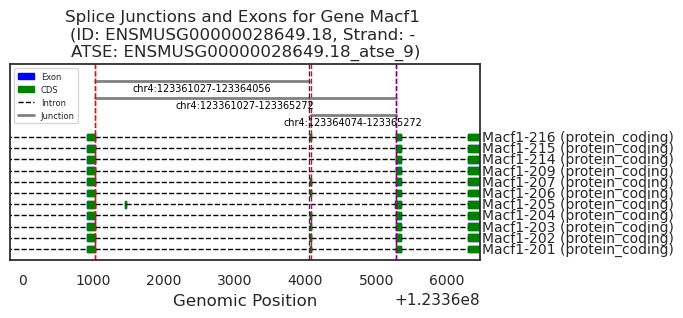

ATSE visualization saved: mouse_ENSMUSG00000028649.18_atse_9.pdf


{'junctions':                            event_id                gene_id gene_name  \
 29933  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 29934  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 29935  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 
            gene_types  num_junctions event_type chromosome strand  atse_start  \
 29933  protein_coding              3    complex       chr4      -   123361027   
 29934  protein_coding              3    complex       chr4      -   123361027   
 29935  protein_coding              3    complex       chr4      -   123361027   
 
         atse_end  ...  donor_total_reads  acceptor_total_reads  splice_motif  \
 29933  123365272  ...             164551                 70767         GT-AG   
 29934  123365272  ...             176645                164551         GT-AG   
 29935  123365272  ...              82861                176645         GT-AG   
 
        donor_seq  acceptor_seq  posi

In [54]:
mouse_event = "ENSMUSG00000028649.18_atse_9"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=7, 
                       trans_height=0.2, 
                  padding=200, show_junc_lines=True)

In [55]:
# save final_df to csv 
final_df.to_csv(f"{OUTPUT_DIR}/final_df.tsv.gz", index=False, sep="\t", compression="gzip")
print(f"Saved final_df to {OUTPUT_DIR}/final_df.tsv.gz")

Saved final_df to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/final_df.tsv.gz


## Check FGFR2 splicing 

In [56]:
splice_adata.var[splice_adata.var["gene_name"] == "FGFR2"]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,...,mean_counts_per_cell,junction_variability,annotation_status_score,expression_breadth_score,read_count_score,variability_score,conservation_score,junction_id_index,RBP_gene,Aging_gene
28305,chr7_130164123_130167702_-,ENSMUSG00000030849.18_atse_5,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,63083,...,10.989609,0.307320,0.8,0.0,10.490135,0.5,2.0,28305,False,False
28306,chr7_130164215_130167702_-,ENSMUSG00000030849.18_atse_5,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,26995,...,7.580279,0.568484,0.8,0.0,9.594514,1.0,2.0,28306,False,False
28307,chr7_130196374_130198418_-,ENSMUSG00000030849.18_atse_4,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,45626,...,14.162311,0.028228,0.8,0.0,9.932706,0.5,2.0,28307,False,False
28308,chr7_130196374_130199757_-,ENSMUSG00000030849.18_atse_4,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,21394,...,10.723684,0.000000,0.8,0.0,9.698982,0.5,2.0,28308,False,False
28309,chr7_130198563_130200982_-,ENSMUSG00000030849.18_atse_3,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,38255,...,13.189681,0.020184,0.8,0.0,9.763363,0.5,2.0,28309,False,False
28310,chr7_130199905_130200982_-,ENSMUSG00000030849.18_atse_3,GT-AG,both,FGFR2,ENSMUSG00000030849,2,1.0,0.0,19571,...,10.186890,0.027905,0.8,0.0,9.589393,0.5,2.0,28310,False,False


In [62]:
splice_adata.layers["denoised_PSI"] = splice_adata.obsm["X_PHI"] @ splice_adata.varm["psi_learned"].T

chr7_130164123_130167702_-
chr7_130164215_130167702_-


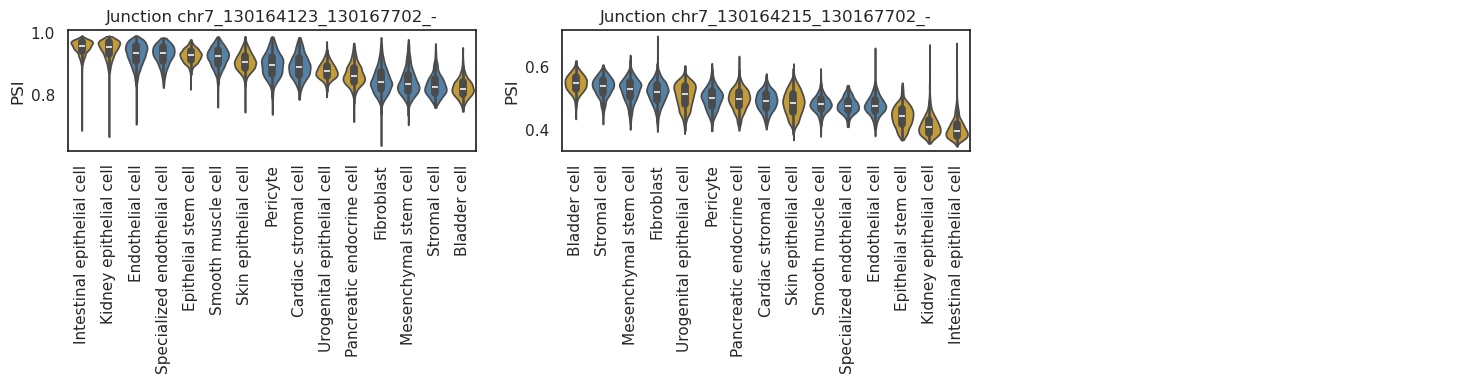

In [75]:
import math

# --- define cell types ---
epi_types = [
    "Skin epithelial cell", "Intestinal epithelial cell", "Urogenital epithelial cell",
    "Epithelial stem cell", "Kidney epithelial cell", "Pancreatic endocrine cell", "Bladder cell"
]
mes_types = [
    "Mesenchymal stem cell", "Fibroblast", "Endothelial cell", "Pericyte",
    "Cardiac stromal cell", "Stromal cell", "Smooth muscle cell", "Specialized endothelial cell"
]
keep_types = epi_types + mes_types
type_colors = {ct: ("goldenrod" if ct in epi_types else "steelblue") for ct in keep_types}

# --- pick ATSE event ---
event_id = "ENSMUSG00000030849.18_atse_5"

# --- get junctions for this ATSE ---
junc_meta = splice_adata.var.loc[splice_adata.var["event_id"] == event_id]
j_indices = junc_meta["junction_id_index"].astype(int).tolist()

# --- prep cell type info ---
cell_types = splice_adata.obs["medium_cell_type"].astype("category")
mask = cell_types.isin(keep_types)
cell_types = cell_types[mask].cat.remove_unused_categories()

# --- loop through junctions ---
n = len(j_indices)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

for idx, (ax, j) in enumerate(zip(axes.ravel(), j_indices)):
    # get PSI column
    col = splice_adata.layers["denoised_PSI"][:, j]
    # get junction_id for this junction 
    junction_id = splice_adata.var["junction_id"][j]
    print(junction_id)
    psi = col.A1 if hasattr(col, "A1") else col
    psi = pd.Series(psi, index=splice_adata.obs_names)[mask]

    df = pd.DataFrame({"PSI": psi.values, "cell_type": cell_types.values})

    # order cell types by decreasing median PSI for this junction
    order = (
        df.groupby("cell_type", observed=True)["PSI"]
          .median()
          .sort_values(ascending=False)
          .index
          .tolist()
    )

    sns.violinplot(
        data=df, x="cell_type", y="PSI",
        inner="box", cut=0, palette=type_colors, order=order, ax=ax
    )
    ax.set_title(f"Junction {junction_id}")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=90)

# hide empty subplots
for ax in axes.ravel()[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


Unique transcripts: ['ENSMUST00000117073.1', 'ENSMUST00000117089.7', 'ENSMUST00000117357.7', 'ENSMUST00000117691.7', 'ENSMUST00000117754.7', 'ENSMUST00000117858.7', 'ENSMUST00000117872.7', 'ENSMUST00000118296.7', 'ENSMUST00000119260.7', 'ENSMUST00000120141.7', 'ENSMUST00000120187.8', 'ENSMUST00000120715.7', 'ENSMUST00000121064.7', 'ENSMUST00000121080.7', 'ENSMUST00000122054.7', 'ENSMUST00000122448.7', 'ENSMUST00000124096.7', 'ENSMUST00000130557.1', 'ENSMUST00000136264.1', 'ENSMUST00000153166.7']
Unique transcripts to remove: []
Plot saved to mouse_ENSMUSG00000030849.18_atse_5.pdf!


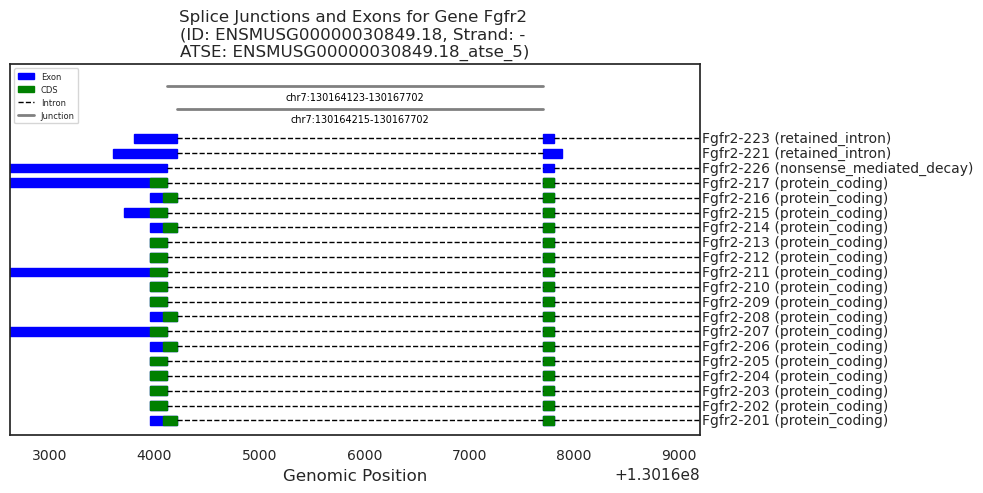

ATSE visualization saved: mouse_ENSMUSG00000030849.18_atse_5.pdf


{'junctions':                            event_id                gene_id gene_name  \
 98097  ENSMUSG00000030849.18_atse_5  ENSMUSG00000030849.18     Fgfr2   
 98098  ENSMUSG00000030849.18_atse_5  ENSMUSG00000030849.18     Fgfr2   
 
            gene_types  num_junctions           event_type chromosome strand  \
 98097  protein_coding              2  alternative_3_prime       chr7      -   
 98098  protein_coding              2  alternative_3_prime       chr7      -   
 
        atse_start   atse_end  ...  donor_total_reads  acceptor_total_reads  \
 98097   130164123  130167702  ...              90187                 26995   
 98098   130164123  130167702  ...              90187                 63083   
 
        splice_motif  donor_seq  acceptor_seq  position_off_5_prime  \
 98097         GT-AG         GT            AG                   1.0   
 98098         GT-AG         GT            AG                   1.0   
 
       position_off_3_prime junction_annotation usage_ratio  \
 98097 

In [74]:
mouse_event = "ENSMUSG00000030849.18_atse_5"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=10, 
                       trans_height=0.2, 
                  padding=500, show_junc_lines=False)